# Multi-Head Attention mit Transformer-Encoder-Logik

## Gemini Code

## Die Glocke Basistext

In [7]:
!mkdir -p /Users/michaelkohlegger/Documents/GitHub/research_experiments/.venv/lib/python3.12/site-packages/tensorflow-plugins/../_solib_darwin_arm64/_U@local_Uconfig_Utf_S_S_C_Upywrap_Utensorflow_Uinternal___Uexternal_Slocal_Uconfig_Utf/

In [8]:
!ln -s /Users/michaelkohlegger/Documents/GitHub/research_experiments/.venv/lib/python3.12/site-packages/tensorflow/python/_pywrap_tensorflow_internal.so /Users/michaelkohlegger/Documents/GitHub/research_experiments/.venv/lib/python3.12/site-packages/tensorflow-plugins/../_solib_darwin_arm64/_U@local_Uconfig_Utf_S_S_C_Upywrap_Utensorflow_Uinternal___Uexternal_Slocal_Uconfig_Utf/_pywrap_tensorflow_internal.so

## MultiHeadAttention Explorieren

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention, Dense, Input
from tensorflow.keras.layers import TextVectorization, Embedding
from tensorflow.keras.layers import LayerNormalization
from numpy import array

import numpy as np
import tensorflow as tf


VOCAB_SIZE = 1000
VEKTOR_LEN = 12
SPLITTING_LEN = 20
EMBEDDING_DIM = 8

NotFoundError: dlopen(/Users/michaelkohlegger/Documents/GitHub/research_experiments/.venv/lib/python3.12/site-packages/tensorflow-plugins/libmetal_plugin.dylib, 0x0006): Symbol not found: __ZN10tensorflow28_AttrValue_default_instance_E
  Referenced from: <8B62586B-B082-3113-93AB-FD766A9960AE> /Users/michaelkohlegger/Documents/GitHub/research_experiments/.venv/lib/python3.12/site-packages/tensorflow-plugins/libmetal_plugin.dylib
  Expected in:     <A9A4EB25-FC26-30FC-9D12-1C4C42DAD518> /Users/michaelkohlegger/Documents/GitHub/research_experiments/.venv/lib/python3.12/site-packages/tensorflow/python/_pywrap_tensorflow_internal.so

In [133]:
text = array([
    "Die Bank hat Sonntags geschlossen",
    "Ich sitze gerade auf der Bank",
    "Diese Aktie ist eine sichere Bank"
])

In [134]:
with open("../data/die_glocke.txt", "r") as file:
    text = file.read().replace("\n", " ").replace("  ", " ").split(" ")

text = [
    " ".join(item) for item in [
        text[i:i+VEKTOR_LEN] for i in range(len(text))
    ]
]

## Eigene Tests

In [113]:
layer_vectorization = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=VEKTOR_LEN
)

layer_vectorization.adapt(text)
input_vector = layer_vectorization(text)

In der folgenden Darstellung können wir sehen, dass das Wort "Bank" beim Vektorisieren immer denselben Wert zugewiesen bekommt. Im aktuellen Beispiel ist das der Wert `2`. Außerdem sehen wir, dass alle Vektoren nach hinten mit dem Wert 0 aufgefüllt werden, um am Ende dieselbe Anzahl von Tokens zu haben (in unserem Fall `VEKTOR_LEN = 12`)

In [114]:
print(input_vector)

tf.Tensor(
[[  3  49  16 ...   1 142   3]
 [ 50  17   1 ...   1 102   1]
 [ 32  69  16 ...   1  33   5]
 ...
 [  3   1  62 ...   5   1   6]
 [  1   1  11 ...   1   8   1]
 [104 109 143 ...   0   0   0]], shape=(171, 12), dtype=int64)


Nun bauen wir unser Netz als Abfolge von Layern auf. Am Ende normalisieren wir in `LayerNormalization` unsere Erregung im Netz. Jeder Feature-Wert wird zentriert und skaliert, sodass die Verteilung einen Mittelwert von 0 und eine Varianz von 1 aufweist. Das kleine Epsilon benutzen wir, um zu verhindern, dass wir eine Division durch 0 erhalten.

In [115]:
layer_input = Input(shape=(VEKTOR_LEN,))
layer_embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)(layer_input)
layer_attention = MultiHeadAttention(num_heads=1, key_dim=EMBEDDING_DIM)(layer_embedding, layer_embedding, layer_embedding)
layer_normalization = LayerNormalization(epsilon=1e-6)(layer_embedding + layer_attention)

In [116]:
model = Model(inputs=layer_input, outputs=layer_normalization)

In [117]:
model.predict(input_vector)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[[-0.911271  , -0.7854687 ,  1.5524099 , ...,  1.236398  ,
         -0.91082144,  1.0224485 ],
        [-0.71958935,  0.4307292 ,  1.690527  , ...,  0.79764104,
         -0.7730874 , -1.0367415 ],
        [-0.01597309, -1.08754   ,  2.1993425 , ...,  0.5533988 ,
         -0.98879707, -0.3732139 ],
        ...,
        [ 1.005703  , -0.07858935,  0.57251465, ..., -1.5124003 ,
         -1.5515705 , -0.28548217],
        [-0.2704513 ,  0.1410394 ,  1.4643614 , ...,  0.34221637,
          0.24416722,  1.033785  ],
        [-0.911271  , -0.7854687 ,  1.5524099 , ...,  1.236398  ,
         -0.91082144,  1.0224485 ]],

       [[ 0.23143339, -1.1775495 ,  1.9906591 , ..., -0.08621955,
          1.0535069 , -0.40822548],
        [ 0.4545522 , -0.03389468, -0.7822808 , ...,  2.3089812 ,
         -0.58651084, -1.0403206 ],
        [ 1.506695  , -0.03246516,  0.36330497, ..., -1.4350345 ,
         -1.6414545 , -0.04957706],
        ...,
        [ 1.506695  , -0.03246516,  0.36330497, ..., -

## Fortschreibungsmodell

In [136]:
# TextVectorization aufsetzen und fitten
layer_vectorization = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=VEKTOR_LEN + 1
)  # +1 weil wir X und Y shiften
layer_vectorization.adapt(text)

# Sätze in Zahlen umwandeln
vectorized_text = layer_vectorization(text)

# X (Eingabe) und Y (Ziel) für das Training erstellen (Verschiebung um 1 Wort)
# X: "Die Bank hat Sonntags" -> Y: "Bank hat Sonntags geschlossen"
X_train = vectorized_text[:, :-1]
Y_train = vectorized_text[:, 1:]

# --- 2. Modellarchitektur (Decoder-Only Transformer Block) ---
layer_input = Input(shape=(VEKTOR_LEN,))

# Embedding
x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)(layer_input)

# Multi-Head Attention mit CAUSAL MASK (verhindert Blick in die Zukunft)
attention_output = MultiHeadAttention(
    num_heads=3, key_dim=EMBEDDING_DIM
)(query=x, value=x, key=x, use_causal_mask=True)

# Residual Connection & Layer Normalization
x = LayerNormalization(epsilon=1e-6)(x + attention_output)

# Output Layer: Pro Position eine Wahrscheinlichkeitsverteilung über das gesamte Vokabular
output = Dense(VOCAB_SIZE, activation="softmax")(x)

# Modell kompilieren
model = Model(inputs=layer_input, outputs=output)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Modell kurz trainieren (auf den wenigen Beispielen)
print("Training läuft...")
log = model.fit(X_train, Y_train, epochs=1000, verbose=1)
print("Training abgeschlossen!\n")


# --- 3. Text-Generierungs-Funktion (Inferenz) ---
def prompt_weiterschreiben(start_text, max_neue_woerter=4):
    vokabular = layer_vectorization.get_vocabulary()

    for _ in range(max_neue_woerter):
        # 1. Aktuellen Text in Zahlen umwandeln
        input_tokens = layer_vectorization([start_text])[:, :-1]

        # 2. Vorhersage für das NÄCHSTE Wort holen
        predictions = model.predict(input_tokens, verbose=0)

        # Wir brauchen die Vorhersage des letzten echten Wortes im Prompt
        # (da der Prompt mit 0 gepaddet ist, suchen wir das Ende des Textes)
        woerter_anzahl = len(start_text.split())
        naechstes_wort_index = np.argmax(predictions[0, woerter_anzahl - 1])

        # 3. Index in Wort zurückübersetzen
        vorhergesagtes_wort = vokabular[naechstes_wort_index]

        # Falls das Modell das Padding-Token [PAD] wählt, brechen wir ab
        if vorhergesagtes_wort == "":
            break

        # 4. Prompt erweitern
        start_text += " " + vorhergesagtes_wort

    return start_text

Training läuft...
Epoch 1/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0682 - loss: 6.7300
Epoch 2/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0834 - loss: 6.2749
Epoch 3/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0852 - loss: 5.7769
Epoch 4/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0826 - loss: 5.3536
Epoch 5/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0776 - loss: 5.0393
Epoch 6/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0743 - loss: 4.7806
Epoch 7/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1024 - loss: 4.5450
Epoch 8/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1548 - loss: 4.3286
Epoch 9/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1947 - loss: 4.1349
Epoch 10/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2195 - loss: 3.9606
Epoch 11/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2416 - loss: 3.8077
Epoch 12/1000
65/65 ━━━━━━━━━━━━━━

In [137]:
print(prompt_weiterschreiben("ich sitze", max_neue_woerter=10))

ich sitze krachen pfosten stürzen fenster klirren kinder jammern mütter irren tiere


In [5]:
import tensorflow_metal as tf

ModuleNotFoundError: No module named 'tensorflow_metal'

In [3]:
devices = tf.config.list_physical_devices()
print("Verfügbare Geräte:", devices)

NameError: name 'tf' is not defined

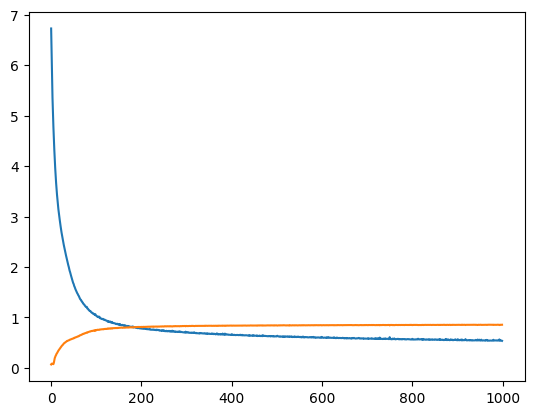

In [139]:
from matplotlib import pyplot as plt

plt.plot(log.history["loss"])
plt.plot(log.history["accuracy"])